**Task-01**

In [1]:
# Tic Tac Toe Evaluation Function
# X is maximizer (+10), O is minimizer (-10)

def evaluate_board(board):
    """
    Evaluate the current board state
    Returns:
    +10 if X wins
    -10 if O wins
    0 if draw or game not finished
    """

    # Check rows for winner
    for row in board:
        if row[0] == row[1] == row[2] and row[0] != '_':
            if row[0] == 'x':
                return 10
            elif row[0] == 'o':
                return -10

    # Check columns for winner
    for col in range(3):
        if board[0][col] == board[1][col] == board[2][col] and board[0][col] != '_':
            if board[0][col] == 'x':
                return 10
            elif board[0][col] == 'o':
                return -10

    # Check diagonals for winner
    # Main diagonal
    if board[0][0] == board[1][1] == board[2][2] and board[0][0] != '_':
        if board[0][0] == 'x':
            return 10
        elif board[0][0] == 'o':
            return -10

    # Anti-diagonal
    if board[0][2] == board[1][1] == board[2][0] and board[0][2] != '_':
        if board[0][2] == 'x':
            return 10
        elif board[0][2] == 'o':
            return -10

    # No winner
    return 0

def is_board_full(board):
    """Check if the board is full"""
    for row in board:
        if '_' in row:
            return False
    return True

def print_board(board):
    """Display the board"""
    print("\nCurrent Board:")
    print("-------------")
    for row in board:
        print("|", end=" ")
        for cell in row:
            print(cell, end=" | ")
        print("\n-------------")

# Test the evaluation function with different board states
def test_evaluation_function():
    # Test Case 1: X wins (row)
    board1 = [
        ['x', 'x', 'x'],
        ['o', '_', 'o'],
        ['_', 'o', '_']
    ]
    print("Test Case 1 - X wins (row):")
    print_board(board1)
    print(f"Evaluation: {evaluate_board(board1)}\n")

    # Test Case 2: O wins (column)
    board2 = [
        ['x', 'o', 'x'],
        ['_', 'o', '_'],
        ['x', 'o', '_']
    ]
    print("Test Case 2 - O wins (column):")
    print_board(board2)
    print(f"Evaluation: {evaluate_board(board2)}\n")

    # Test Case 3: Draw
    board3 = [
        ['x', 'o', 'x'],
        ['x', 'o', 'o'],
        ['o', 'x', 'x']
    ]
    print("Test Case 3 - Draw:")
    print_board(board3)
    print(f"Evaluation: {evaluate_board(board3)}\n")

    # Test Case 4: X wins (diagonal)
    board4 = [
        ['x', 'o', '_'],
        ['_', 'x', 'o'],
        ['_', '_', 'x']
    ]
    print("Test Case 4 - X wins (diagonal):")
    print_board(board4)
    print(f"Evaluation: {evaluate_board(board4)}\n")

    # Test Case 5: O wins (anti-diagonal)
    board5 = [
        ['x', 'x', 'o'],
        ['x', 'o', '_'],
        ['o', '_', '_']
    ]
    print("Test Case 5 - O wins (anti-diagonal):")
    print_board(board5)
    print(f"Evaluation: {evaluate_board(board5)}")

# Run the tests
if __name__ == "__main__":
    test_evaluation_function()

Test Case 1 - X wins (row):

Current Board:
-------------
| x | x | x | 
-------------
| o | _ | o | 
-------------
| _ | o | _ | 
-------------
Evaluation: 10

Test Case 2 - O wins (column):

Current Board:
-------------
| x | o | x | 
-------------
| _ | o | _ | 
-------------
| x | o | _ | 
-------------
Evaluation: -10

Test Case 3 - Draw:

Current Board:
-------------
| x | o | x | 
-------------
| x | o | o | 
-------------
| o | x | x | 
-------------
Evaluation: 0

Test Case 4 - X wins (diagonal):

Current Board:
-------------
| x | o | _ | 
-------------
| _ | x | o | 
-------------
| _ | _ | x | 
-------------
Evaluation: 10

Test Case 5 - O wins (anti-diagonal):

Current Board:
-------------
| x | x | o | 
-------------
| x | o | _ | 
-------------
| o | _ | _ | 
-------------
Evaluation: -10


**Task-02**

In [ ]:
import tkinter as tk
from tkinter import messagebox
import numpy as np

class TicTacToeGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Tic Tac Toe - Evaluation Function")
        self.root.geometry("400x500")
        self.root.resizable(False, False)

        # Game variables
        self.board = [['_' for _ in range(3)] for _ in range(3)]
        self.current_player = 'x'  # x starts (maximizer)
        self.buttons = []
        self.game_over = False

        # Create GUI elements
        self.create_widgets()

    def create_widgets(self):
        # Title frame
        title_frame = tk.Frame(self.root, bg='lightblue', height=80)
        title_frame.pack(fill=tk.X)

        title_label = tk.Label(
            title_frame,
            text="Tic Tac Toe\nEvaluation Function Demo",
            font=('Arial', 16, 'bold'),
            bg='lightblue',
            fg='navy'
        )
        title_label.pack(expand=True, pady=10)

        # Player info frame
        info_frame = tk.Frame(self.root, bg='lightgray', height=40)
        info_frame.pack(fill=tk.X)

        self.info_label = tk.Label(
            info_frame,
            text="Current Player: X (Maximizer)",
            font=('Arial', 12),
            bg='lightgray'
        )
        self.info_label.pack(pady=5)

        # Game board frame
        board_frame = tk.Frame(self.root, bg='black', padx=10, pady=10)
        board_frame.pack(expand=True)

        # Create 3x3 grid of buttons
        for i in range(3):
            row_buttons = []
            for j in range(3):
                button = tk.Button(
                    board_frame,
                    text='',
                    font=('Arial', 24, 'bold'),
                    width=3,
                    height=1,
                    bg='white',
                    command=lambda row=i, col=j: self.make_move(row, col)
                )
                button.grid(row=i, column=j, padx=2, pady=2)
                row_buttons.append(button)
            self.buttons.append(row_buttons)

        # Control buttons frame
        control_frame = tk.Frame(self.root, bg='lightgray', height=80)
        control_frame.pack(fill=tk.X, side=tk.BOTTOM)

        # Evaluation display
        eval_frame = tk.Frame(control_frame, bg='lightgray')
        eval_frame.pack(pady=5)

        tk.Label(
            eval_frame,
            text="Board Value:",
            font=('Arial', 11, 'bold'),
            bg='lightgray'
        ).pack(side=tk.LEFT, padx=5)

        self.eval_label = tk.Label(
            eval_frame,
            text="0",
            font=('Arial', 14, 'bold'),
            bg='white',
            width=6,
            relief=tk.SUNKEN
        )
        self.eval_label.pack(side=tk.LEFT, padx=5)

        # Control buttons
        button_frame = tk.Frame(control_frame, bg='lightgray')
        button_frame.pack(pady=10)

        reset_btn = tk.Button(
            button_frame,
            text="New Game",
            font=('Arial', 11),
            bg='green',
            fg='white',
            width=10,
            command=self.reset_game
        )
        reset_btn.pack(side=tk.LEFT, padx=5)

        analyze_btn = tk.Button(
            button_frame,
            text="Analyze Board",
            font=('Arial', 11),
            bg='blue',
            fg='white',
            width=10,
            command=self.show_analysis
        )
        analyze_btn.pack(side=tk.LEFT, padx=5)

    def make_move(self, row, col):
        """Handle player moves"""
        if self.game_over:
            return

        if self.board[row][col] == '_':
            # Update board
            self.board[row][col] = self.current_player

            # Update button
            display_text = 'X' if self.current_player == 'x' else 'O'
            color = 'blue' if self.current_player == 'x' else 'red'
            self.buttons[row][col].config(
                text=display_text,
                fg=color,
                state=tk.DISABLED
            )

            # Check game state
            self.check_game_state()

            # Switch player
            self.current_player = 'o' if self.current_player == 'x' else 'x'
            player_display = 'X (Maximizer)' if self.current_player == 'x' else 'O (Minimizer)'
            self.info_label.config(text=f"Current Player: {player_display}")

            # Update evaluation
            self.update_evaluation()

    def evaluate_board(self):
        """Evaluation function implementation"""
        board = self.board

        # Check rows
        for row in board:
            if row[0] == row[1] == row[2] and row[0] != '_':
                return 10 if row[0] == 'x' else -10

        # Check columns
        for col in range(3):
            if board[0][col] == board[1][col] == board[2][col] and board[0][col] != '_':
                return 10 if board[0][col] == 'x' else -10

        # Check main diagonal
        if board[0][0] == board[1][1] == board[2][2] and board[0][0] != '_':
            return 10 if board[0][0] == 'x' else -10

        # Check anti-diagonal
        if board[0][2] == board[1][1] == board[2][0] and board[0][2] != '_':
            return 10 if board[0][2] == 'x' else -10

        return 0

    def check_game_state(self):
        """Check if game is won or drawn"""
        score = self.evaluate_board()

        if score == 10:
            messagebox.showinfo("Game Over", "X (Maximizer) wins!\nBoard Value: +10")
            self.game_over = True
            self.disable_all_buttons()
        elif score == -10:
            messagebox.showinfo("Game Over", "O (Minimizer) wins!\nBoard Value: -10")
            self.game_over = True
            self.disable_all_buttons()
        elif self.is_board_full():
            messagebox.showinfo("Game Over", "It's a draw!\nBoard Value: 0")
            self.game_over = True

    def is_board_full(self):
        """Check if board is full"""
        for row in self.board:
            if '_' in row:
                return False
        return True

    def disable_all_buttons(self):
        """Disable all buttons when game is over"""
        for i in range(3):
            for j in range(3):
                self.buttons[i][j].config(state=tk.DISABLED)

    def update_evaluation(self):
        """Update the evaluation display"""
        score = self.evaluate_board()
        color = 'green' if score > 0 else 'red' if score < 0 else 'black'
        self.eval_label.config(text=str(score), fg=color)

    def reset_game(self):
        """Reset the game board"""
        self.board = [['_' for _ in range(3)] for _ in range(3)]
        self.current_player = 'x'
        self.game_over = False

        # Reset buttons
        for i in range(3):
            for j in range(3):
                self.buttons[i][j].config(
                    text='',
                    bg='white',
                    state=tk.NORMAL
                )

        # Reset labels
        self.info_label.config(text="Current Player: X (Maximizer)")
        self.eval_label.config(text="0", fg='black')

    def show_analysis(self):
        """Show detailed board analysis"""
        score = self.evaluate_board()
        board_state = "Current Board Analysis:\n\n"

        # Display board in message
        for i in range(3):
            row_display = ""
            for j in range(3):
                cell = self.board[i][j]
                if cell == '_':
                    row_display += " - "
                else:
                    row_display += f" {cell.upper()} "
            board_state += row_display + "\n"

        board_state += f"\nEvaluation Score: {score}\n"

        if score == 10:
            board_state += "Result: X wins (+10)"
        elif score == -10:
            board_state += "Result: O wins (-10)"
        else:
            board_state += "Result: No winner (0)"

        messagebox.showinfo("Board Analysis", board_state)

# Run the application
if __name__ == "__main__":
    root = tk.Tk()
    app = TicTacToeGUI(root)
    root.mainloop()

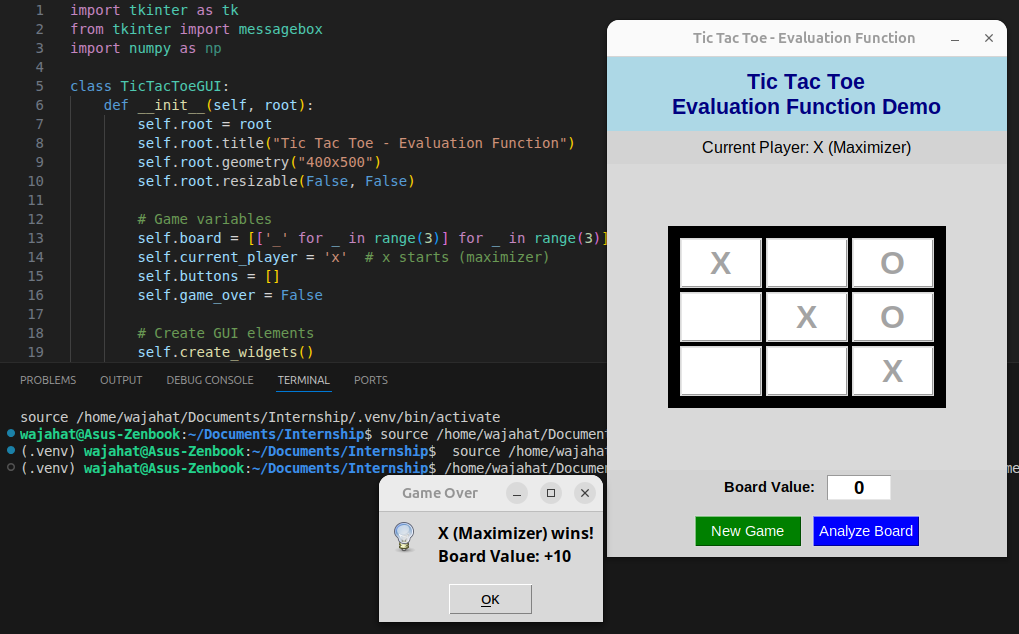